In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import gensim
import nltk

from gensim.models import Word2Vec
from urllib.parse import urlparse

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import MinMaxScaler

from nltk.tokenize import casual_tokenize, word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

import matplotlib.pyplot as plt

nltk.download('punkt_tab')      
nltk.download('wordnet')    
nltk.download('omw-1.4') 
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /home/tkl/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /home/tkl/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/tkl/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/tkl/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to /home/tkl/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
# READ DATA

In [3]:
original_data = pd.read_csv('/var/my-data/ds-1-url/dataset_phishing.csv')
original_data

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11425,http://www.fontspace.com/category/blackletter,45,17,0,2,0,0,0,0,0,...,0,0,0,448,5396,3980,0,0,6,legitimate
11426,http://www.budgetbots.com/server.php/Server%20...,84,18,0,5,0,1,1,0,0,...,1,0,0,211,6728,0,0,1,0,phishing
11427,https://www.facebook.com/Interactive-Televisio...,105,16,1,2,6,0,1,0,0,...,0,0,0,2809,8515,8,0,1,10,legitimate
11428,http://www.mypublicdomainpictures.com/,38,30,0,2,0,0,0,0,0,...,1,0,0,85,2836,2455493,0,0,4,legitimate


In [4]:
# TRIM DATA - simplify the data into 'url' and 'status' columns only for baseline analysis.
# This analysis will only focus on tokenizing and vector embedding for words in a URL.
# More lexical features should be added for in depth analysis.

In [5]:
trimmed_data = original_data.filter(items=['url', 'status'])
trimmed_data

,url,status
0,http://www.crestonwood.com/router.php,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,phishing
2,https://support-appleld.com.secureupdate.duila...,phishing
3,http://rgipt.ac.in,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,legitimate
...,...,...
11425,http://www.fontspace.com/category/blackletter,legitimate
11426,http://www.budgetbots.com/server.php/Server%20...,phishing
11427,https://www.facebook.com/Interactive-Televisio...,legitimate
11428,http://www.mypublicdomainpictures.com/,legitimate


In [6]:
# NULL VALUE CHECK

In [7]:
assert((True in trimmed_data.isna().values) == False)

In [8]:
# DATA STATISTICS - both URL types (phishing, legit) are present and distributed equally.

In [9]:
trimmed_data.describe()

,url,status
count,11430,11430
unique,11429,2
top,http://e710z0ear.du.r.appspot.com/c:/users/use...,legitimate
freq,2,5715


In [10]:
trimmed_data['status'].value_counts(normalize=True)

status
legitimate    0.5
phishing      0.5
Name: proportion, dtype: float64

In [11]:
# DATA REFORMAT - map text to number for model fitting.

In [12]:
status_mapping = {'legitimate': 0, 'phishing': 1}
trimmed_data['status'] = trimmed_data['status'].map(lambda x: status_mapping[x]).astype(int)
trimmed_data

,url,status
0,http://www.crestonwood.com/router.php,0
1,http://shadetreetechnology.com/V4/validation/a...,1
2,https://support-appleld.com.secureupdate.duila...,1
3,http://rgipt.ac.in,0
4,http://www.iracing.com/tracks/gateway-motorspo...,0
...,...,...
11425,http://www.fontspace.com/category/blackletter,0
11426,http://www.budgetbots.com/server.php/Server%20...,1
11427,https://www.facebook.com/Interactive-Televisio...,0
11428,http://www.mypublicdomainpictures.com/,0


In [13]:
# DATA PARTITION - split into training datasets and testing set.

In [14]:
X = trimmed_data[['url']]
y = trimmed_data[['status']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [15]:
# DATA PREPROCESSING

In [16]:
sample_url = X_train['url'].iat[1]

In [17]:
## URL Tokenization

delims_generic = ['://', '/', '?', '&', '=', '.']
delims_other = ['-', '_']

def token_expand(token):
    '''Used for tokenizing website specific delimiters'''
    
    tokens = [token]

    for delim in (delims_generic + delims_other):
        new_tokens = []

        for t in tokens:
            if delim in t:
                new_tokens.extend(t.split(delim))
            else:
                new_tokens.extend(word_tokenize(t))

        tokens = new_tokens

    return tokens
        
def url_to_tokens(url):
    tokens = []
    url_obj = urlparse(url)
    
    for part in url_obj:
        if part:
            part_tokens = casual_tokenize(part.lower())
            tokens.extend(part_tokens)

    expanded_tokens = []
    
    for t in tokens:
        toks = token_expand(t)
        expanded_tokens.extend(toks)

    lemmatizer = WordNetLemmatizer()
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in expanded_tokens]
    
    filtered_words = [word for word in lemmatized_tokens if word not in stopwords.words('english')]

    filtered_words = [word for word in filtered_words if word] # removes empty strings

    return filtered_words
    
print(url_to_tokens(sample_url))

['http', 'www', 'howtogeek', 'com', '70494', 'kind', 'ethernet', 'cat', '5e6a', 'cable', 'use']


In [18]:
## Create a Bag of Words representation for extracted features

### Create token counter - this will be used to extract features based on some criteria 

token_counter = {}

for url in X_train['url']:
    url_tokens = url_to_tokens(url)
    for t in url_tokens:
        if t not in token_counter:
            token_counter[t] = 1
        token_counter[t] += 1

len(token_counter)

16508

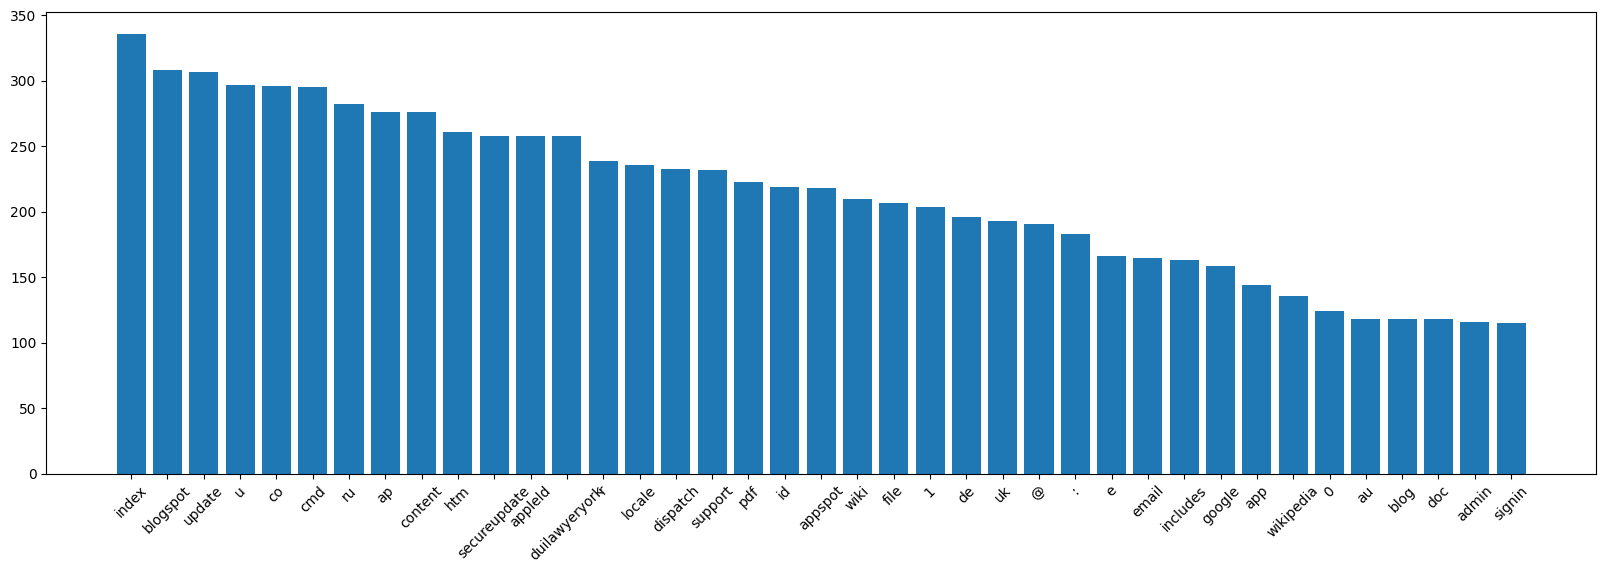

In [19]:
### Visualizing the token counter for fine-tuning criteria

token_counter_value_sorted = dict(sorted(token_counter.items(), key=lambda x: x[1], reverse=True)[11:50])

plt.figure(figsize=(20, 6))
plt.xticks(rotation=45)
plt.bar(token_counter_value_sorted.keys(), token_counter_value_sorted.values())
plt.show()

In [20]:
### Extract features based on criteria

def keep_token(processed_token, threshold=(100, 350)):
    '''
    Keep the token if it is in `token_counter` and is within the threshold.
    This is how feature is chosen.
    '''
    
    if processed_token not in token_counter:
        return False
    else:
        return threshold[0] < token_counter[processed_token] and token_counter[processed_token] < threshold[1]

In [21]:
features = []
for token in token_counter:
    if keep_token(token, (1, 350)):
        features.append(token)

token_to_index_map = {t:i for i, t in enumerate(features)}

In [22]:
### Create a URL to vector converter - this is the Bag of Words representation of URL

def url_to_count_vec(url):
    count_vec = np.zeros(len(features))
    tokens = url_to_tokens(url)
    
    for t in tokens:
        if t not in features:
            continue
        index = token_to_index_map[t]
        count_vec[index] += 1
        
    return count_vec

print(sample_url)
url_to_count_vec(sample_url)

https://www.howtogeek.com/70494/what-kind-of-ethernet-cat-5e6a-cable-should-i-use/


array([0., 0., 0., ..., 0., 0., 0.], shape=(16497,))

In [23]:
# GET DATA READY FOR TRAINING, SCALING

In [24]:
X_train_pp = np.array([url_to_count_vec(u) for u in X_train['url']]).astype(int)
y_train_pp = y_train['status'].to_numpy().astype(int)

X_test_pp = np.array([url_to_count_vec(u) for u in X_test['url']]).astype(int)
y_test_pp = y_test['status'].to_numpy().astype(int)

In [25]:
X_train_pp.shape, y_train_pp.shape, X_test_pp.shape, y_test_pp.shape

((8572, 16497), (8572,), (2858, 16497), (2858,))

In [26]:
## Scaling data

scaler = MinMaxScaler().fit(X_train_pp)
X_train_pp_scaled, X_test_pp_scaled = scaler.transform(X_train_pp), scaler.transform(X_test_pp)
X_train_pp_scaled

array([[1., 1., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 1., 1.]], shape=(8572, 16497))

In [27]:
## Training

lr = LogisticRegression().fit(X_train_pp_scaled, y_train_pp)
print(classification_report(y_test_pp, lr.predict(X_test_pp_scaled)))

              precision    recall  f1-score   support

           0       0.83      0.95      0.89      1422
           1       0.94      0.81      0.87      1436

    accuracy                           0.88      2858
   macro avg       0.89      0.88      0.88      2858
weighted avg       0.89      0.88      0.88      2858



In [29]:
#url = 'http://rapidpaws.com/wp-content/we_transfer/index2.php?email=/' correct
#url = 'https://trezordevicehelp.com/captcha/' wrong
url = 'http://unsub-ns.net/unsubscribe/55/9999/1/48c7dc483b5d4f04d24dce567c670297/?s1=#affid#&s2=#s1#' # correct

vec = url_to_count_vec(url)
vec = scaler.transform(vec.reshape(1, -1))
pred = lr.predict(vec)
pred

array([1])